In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Admission_Predict.csv')

In [9]:
df.head()


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [8]:
df.shape

(400, 9)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop(columns=['Serial No.'] , inplace=True)

In [14]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
# Select all columns except the last column as input features (X)
X = df.iloc[:, :-1]

# Select the last column as the target/output variable (y)
y = df.iloc[:, -1]

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
)

In [21]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
93,301,97,2,3.0,3.0,7.88,1
23,334,119,5,5.0,4.5,9.70,1
299,305,112,3,3.0,3.5,8.65,0
13,307,109,3,4.0,3.0,8.00,1
90,318,106,2,4.0,4.0,7.92,1
...,...,...,...,...,...,...,...
255,307,110,4,4.0,4.5,8.37,0
72,321,111,5,5.0,5.0,9.45,1
396,325,107,3,3.0,3.5,9.11,1
235,326,111,5,4.5,4.0,9.23,1


In [24]:
y_train

93     0.44
23     0.95
299    0.71
13     0.62
90     0.64
       ... 
255    0.79
72     0.93
396    0.84
235    0.88
37     0.58
Name: Chance of Admit , Length: 320, dtype: float64

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [27]:
X_train_scaled

array([[0.22      , 0.17857143, 0.25      , ..., 0.42857143, 0.25      ,
        1.        ],
       [0.88      , 0.96428571, 1.        , ..., 0.85714286, 0.91911765,
        1.        ],
       [0.3       , 0.71428571, 0.5       , ..., 0.57142857, 0.53308824,
        0.        ],
       ...,
       [0.7       , 0.53571429, 0.5       , ..., 0.57142857, 0.70220588,
        1.        ],
       [0.72      , 0.67857143, 1.        , ..., 0.71428571, 0.74632353,
        1.        ],
       [0.2       , 0.46428571, 0.        , ..., 0.14285714, 0.22058824,
        0.        ]], shape=(320, 7))

In [ ]:

import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [62]:
# neural n/w architecture  built krna hai

model = Sequential()
model.add(Dense(7,activation="relu",input_dim=7))
model.add(Dense(7,activation="relu"))
model.add(Dense(7,activation="relu"))
model.add(Dense(1,activation='linear'))

e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176 (704.00 B)

 Trainable params: 176 (704.00 B)

 Non-trainable params: 0 (0.00 B)

In [70]:
# compiling
model.compile(loss="mse",optimizer="Adam", metrics=["mae"])

In [71]:
History = model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0042 - mae: 0.0468 - val_loss: 0.0045 - val_mae: 0.0491
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - mae: 0.0484 - val_loss: 0.0059 - val_mae: 0.0629
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0043 - mae: 0.0487 - val_loss: 0.0045 - val_mae: 0.0502
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0040 - mae: 0.0452 - val_loss: 0.0050 - val_mae: 0.0554
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - mae: 0.0461 - val_loss: 0.0045 - val_mae: 0.0505
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0042 - mae: 0.0468 - val_loss: 0.0049 - val_mae: 0.0547
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0041 - mae: 0.0454 - val_loss: 0.0047 - val_mae: 0.0522
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - mae: 0.0455 - val_loss: 0.0046 - val_mae: 0.0510
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0040 - mae: 0.0448 - val_loss: 0

In [66]:
# prediction
y_pred = model.predict(X_test_scaler)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [75]:
# RMSE

from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE:", rmse)

RMSE: 0.07010778352216575


In [76]:
# R² Score

from sklearn.metrics import r2_score
r2 =r2_score(y_test,y_pred)
print("R2 Score:", r2)

R2 Score: 0.7874774794920165


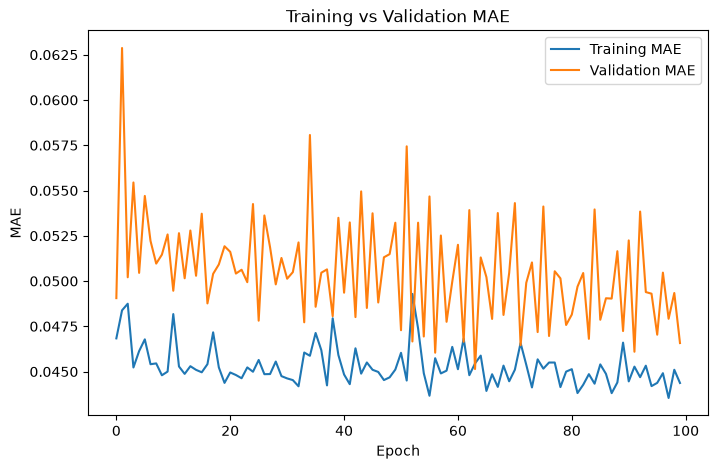

In [72]:
# MAE Graph

import os
import matplotlib.pyplot as plt

os.makedirs("results", exist_ok=True)

plt.figure(figsize=(8,5))

plt.plot(History.history["mae"], label="Training MAE")
plt.plot(History.history["val_mae"], label="Validation MAE")

plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.savefig("results/mae_curve.png", dpi=300, bbox_inches="tight")
plt.show()

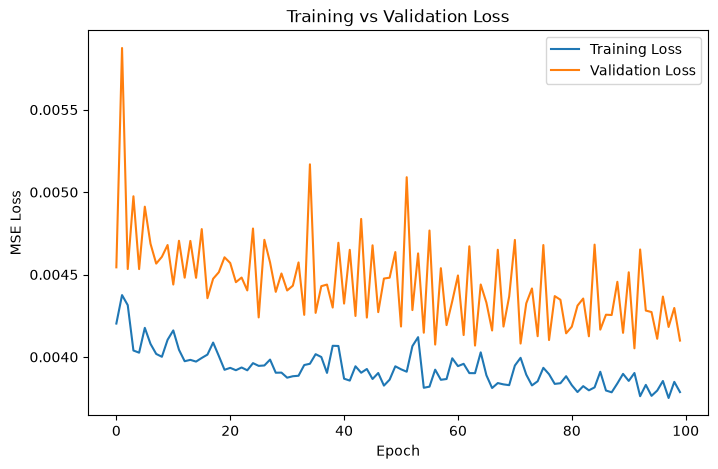

In [74]:
# Loss Graph

# Create results folder if it doesn't exist
os.makedirs("results", exist_ok=True)

plt.figure(figsize=(8,5))

plt.plot(History.history["loss"], label="Training Loss")
plt.plot(History.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.savefig("results/loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

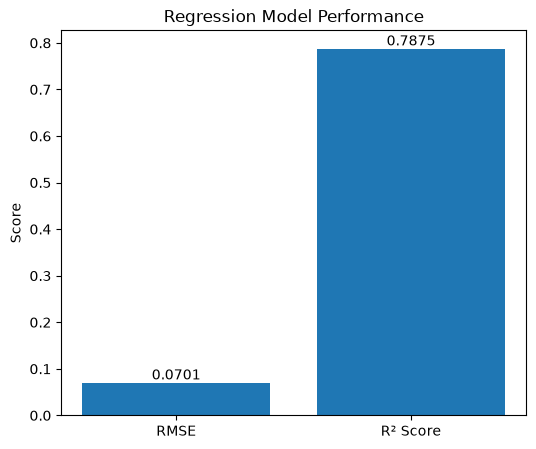

In [77]:
# RMSE & R² Score Plot

import os
import matplotlib.pyplot as plt

# Create results folder if it doesn't exist
os.makedirs("results", exist_ok=True)

# Metrics
metrics = ["RMSE", "R² Score"]
values = [rmse, r2]

plt.figure(figsize=(6,5))

plt.bar(metrics, values)

plt.title("Regression Model Performance")
plt.ylabel("Score")

# Show values on bars
for i, v in enumerate(values):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=10)

# Save figure
plt.savefig("results/regression_metrics.png", dpi=300, bbox_inches="tight")

plt.show()

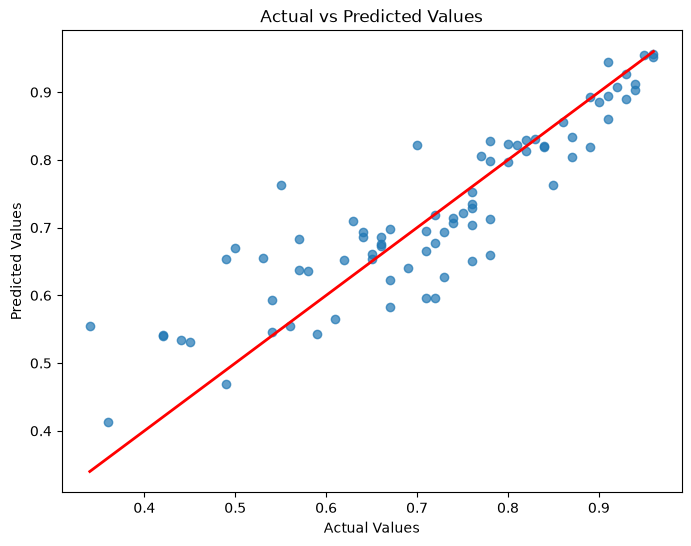

In [78]:
# Actual vs Predicted Values

import os
import matplotlib.pyplot as plt

os.makedirs("results", exist_ok=True)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.savefig("results/actual_vs_predicted.png",
            dpi=300,
            bbox_inches="tight")

plt.show()